In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

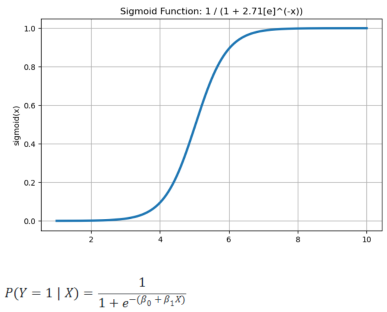

In [ ]:
'''
In math, e is a famous number called Euler's number (pronounced "Oiler's number"). 
It is a constant—a fixed number like pi (π)—that is roughly equal to 2.71828
'''

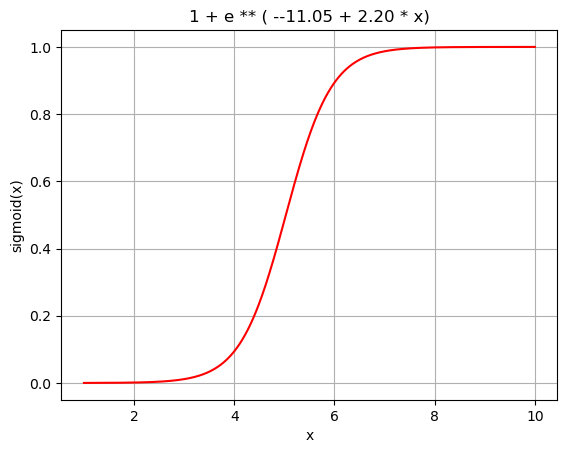

In [49]:
import math
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 10, 500)

# e = 2.718281828459045                                 --- or math.e
b0 = -11.052
b1 = 2.197

denom = 1 + np.exp(-(b0 + b1 * x))
sigmoid = 1 / denom
plt.plot(x, sigmoid, color='r')
plt.title(f'1 + e ** ( -{b0:.2f} + {b1:.2f} * x)')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid()
# plt.scatter(x.flatten(), sigmoid, color='r', marker='o', s=50, zorder=5, label='Training Data')
plt.show()

-1.0375713764547307
0.3815562393392072


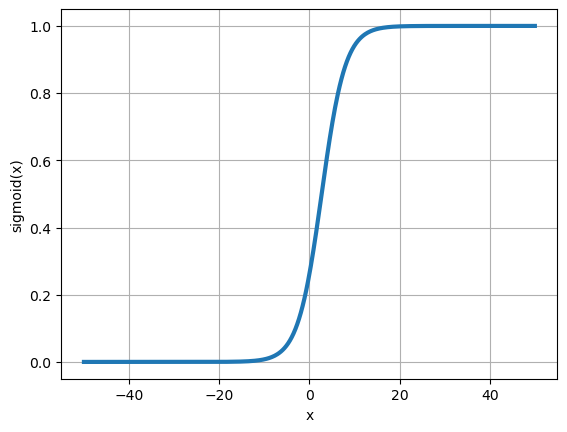

x=3:  52.67%
x=3:  [1]
x=3:  [[no/yes]] = [[0.47325123 0.52674877]]


In [51]:
from sklearn.linear_model import LogisticRegression

X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
Y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

model = LogisticRegression(solver='liblinear')
model.fit(X, Y)

b0 = model.intercept_[0]
b1 = model.coef_[0][0]

print(b0)
print(b1)

x = np.linspace(-50, 50, 500)

denom = 1 + np.exp( -(b0 + b1 * x) )
sigmoid = 1 / denom
plt.plot(x, sigmoid, linewidth = 3)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(True)
# plt.scatter(X.flatten(), Y, color='red', marker='o', s=50, zorder=5, label='Training Data')

plt.show()

# what is the answer for x = 3?
# 1 solve for x = 3
# 2 predict

print('x=3: ', f'{1 /  (1 + np.exp( -(b0 + b1 * 3) )) * 100:.2f}%')
print('x=3: ', model.predict([[3]]))
print('x=3:  [[no/yes]] =', model.predict_proba([[3]]))


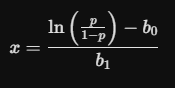

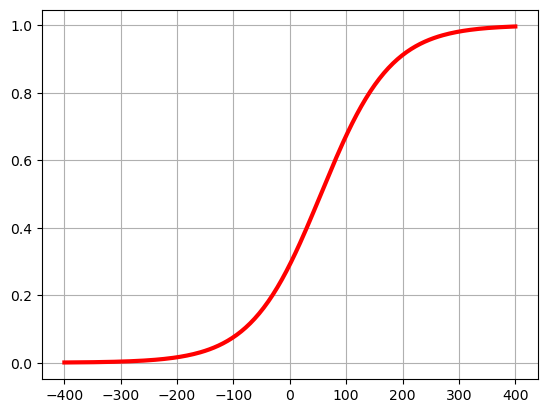

equation: 1 / (1 + e^(0.8904-0.02x))
49k: 47.48
55k: 49.90
Exact x for 70% -> 107.84
Exact x for 80% -> 141.29
get_prob(model, 50) -> 47.88%
Decision for x=50: no
Decision for x=107.84: yes


In [122]:
# Data: Annual income and loan repayment (1=yes, 0=no)
X = np.array([30, 35, 40, 45, 50, 55, 60, 65, 70, 75]).reshape(-1, 1)
Y = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1])
 
# create model with solve liblinear + fit
# build the equation
# draw the graph
# what is the proba of 49? 55? in percentage
# build func that get x and return percentage
# detect for which x the P is 70%
# build a funciton that get x and print yes for 70% and no for less (using the last question)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver = 'liblinear')
model.fit(X, Y)

b0 = model.intercept_[0]
b1 = model.coef_[0][0]

x = np.linspace(-400, 400, 200)
denom = 1 + np.exp( -(b0 + b1 * x))
sigmoid = 1 / denom

plt.plot(x, sigmoid, linewidth = 3, color='r')
plt.grid(True)
plt.show()

print(f'equation: 1 / (1 + e^({-b0:.4f}-{b1:.2f}x))')

print(f'49k: {(model.predict_proba([[49]])[0][1])*100:.2f}')
print(f'55k: {(model.predict_proba([[55]])[0][1])*100:.2f}')

def get_prob(model, check):
    return round((model.predict_proba([[check]])[0][1])*100, 2)


x_70 = (np.log(0.7 / 0.3) - b0) / b1
print(f'Exact x for 70% -> {x_70:.2f}')

x_80 = (np.log(0.8 / 0.2) - b0) / b1
print(f'Exact x for 80% -> {x_80:.2f}')

def yes_no_70(model, check):
    """Returns 'yes' if probability is >= 70%, otherwise 'no'."""
    prob = model.predict_proba([[check]])[0][1] * 100
    if prob >= 70:
        return 'yes'
    return 'no'
    

    
print(f'get_prob(model, 50) -> {get_prob(model, 50)}%')

print(f'Decision for x=50: {yes_no_70(model, 50)}')
print(f'Decision for x=107.84: {yes_no_70(model, 107.85)}')

